# Appliquer le filtre Perona-Malik sur l'image

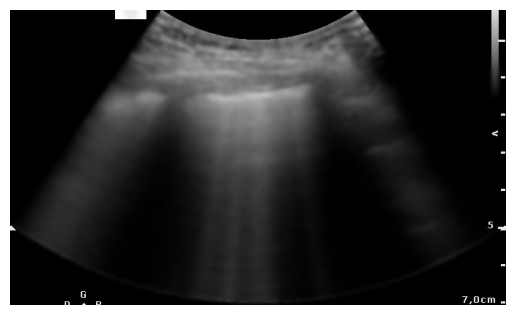

In [10]:
import numpy as np
import cv2
import warnings
import matplotlib.pyplot as plt
from PIL import Image

def anisodiff(img, niter=1, kappa=50, gamma=0.1, step=(1., 1.), option=1, ploton=False):
    if img.ndim == 3:
        warnings.warn("Only grayscale images allowed, converting to 2D matrix")
        img = img.mean(2)
    
    # Initialize output array
    img = img.astype('float32')
    imgout = img.copy()

    # Initialize some internal variables
    deltaS = np.zeros_like(imgout)
    deltaE = deltaS.copy()
    NS = deltaS.copy()
    EW = deltaS.copy()
    gS = np.ones_like(imgout)
    gE = gS.copy()

    for ii in range(niter):
        # Calculate the diffs
        deltaS[:-1, :] = np.diff(imgout, axis=0)
        deltaE[:, :-1] = np.diff(imgout, axis=1)

        # Conduction gradients (only need to compute one per dim!)
        if option == 1:
            gS = np.exp(-(deltaS / kappa) ** 2.) / step[0]
            gE = np.exp(-(deltaE / kappa) ** 2.) / step[1]
        elif option == 2:
            gS = 1. / (1. + (deltaS / kappa) ** 2.) / step[0]
            gE = 1. / (1. + (deltaE / kappa) ** 2.) / step[1]

        # Update matrices
        E = gE * deltaE
        S = gS * deltaS

        # Subtract a copy that has been shifted 'North/West' by one pixel
        NS[:] = S
        EW[:] = E
        NS[1:, :] -= S[:-1, :]
        EW[:, 1:] -= E[:, :-1]

        # Update the image
        imgout += gamma * (NS + EW)

    return np.clip(imgout, 0, 255).astype(np.uint8)

image = cv2.imread('Patients/Patients/20Patient 1LC20/1020M0/201902/2019010K.jpg', cv2.IMREAD_GRAYSCALE)
# image = cv2.imread('Patients/Patients/17Patient 1SG17/1017M0/201900/20190106.jpg', cv2.IMREAD_GRAYSCALE)

img_array_sp = np.array(image)

anisodiff_img_sp = anisodiff(img_array_sp, niter=30, kappa=50, gamma=0.1)

image = Image.fromarray(anisodiff_img_sp)

image.save('foo.jpg')

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()


# FindContours de cv2 pour détecter la ligne pleurale (généralement la ligne la plus grande et la plus en bas) + remplacer les bords de l'image par des pixels noirs 

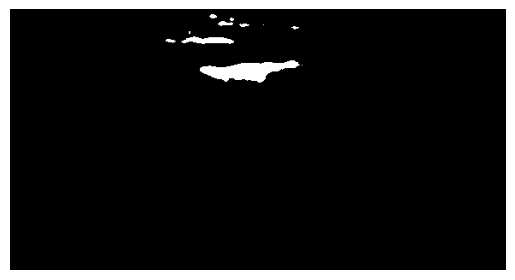

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# image = cv2.imread('Patients/Patients/20Patient 1LC20/1020M0/201902/2019010K.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.imread('foo.jpg', cv2.IMREAD_GRAYSCALE)

margin = 50
height, width = image.shape[:2]

cropped_image = image[margin:height-margin, margin:width-margin]

_, binary_image = cv2.threshold(cropped_image, 150, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = np.zeros_like(cropped_image)

cv2.drawContours(output, contours, -1, (255), thickness=cv2.FILLED)

plt.imshow(output, cmap='gray')
plt.axis('off')
plt.show()


# FindContour + recadrage de l'image en dessous de la ligne pleurale + test de plusieur threshold pour essayer de trouver les lignes B
Fonctionne pas trop, car c'est une méthode très simple. Ouvrir le sujet sur la segmentation d'object, ce qui implique de faire de l'annotation sur chaque image + modèle de segmentation (peu surrement être implémenter assez rapidement avec huggging face)

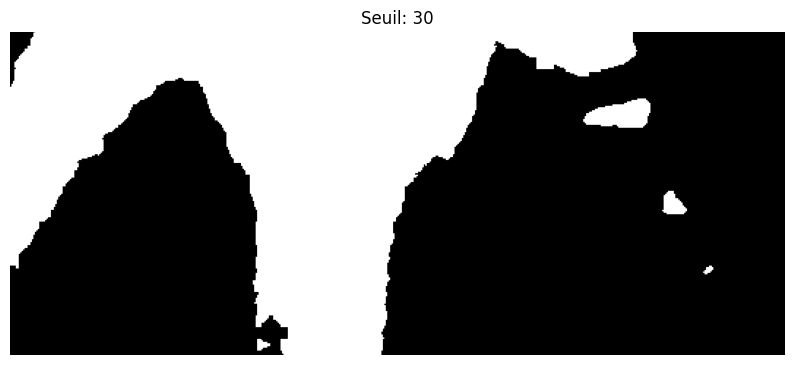

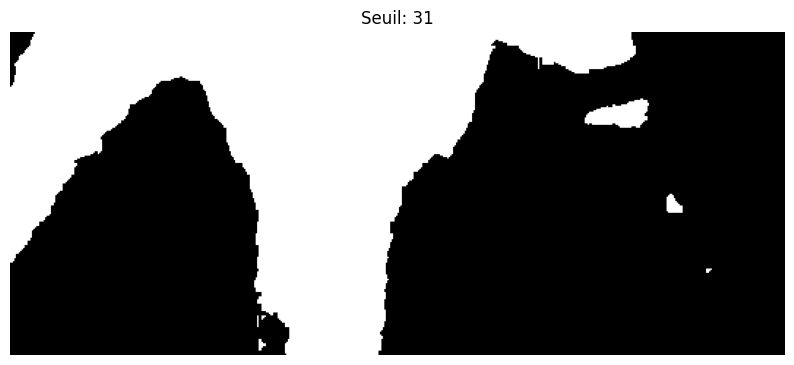

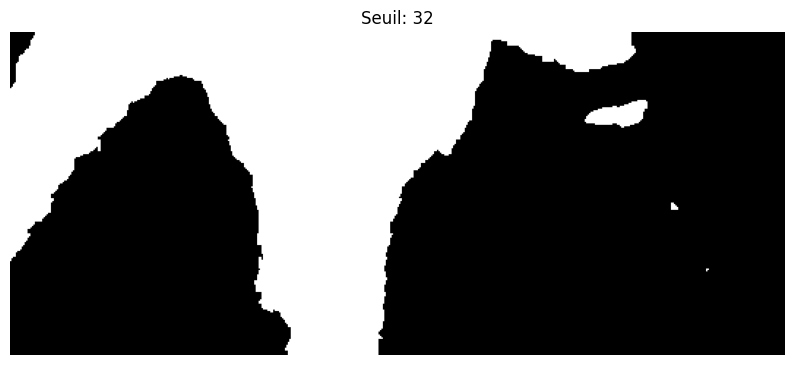

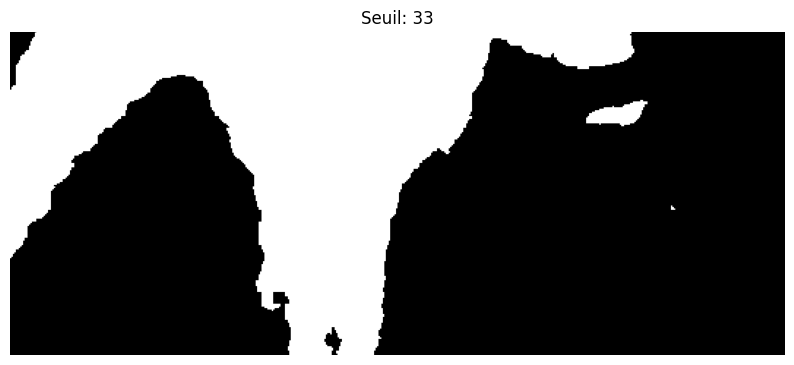

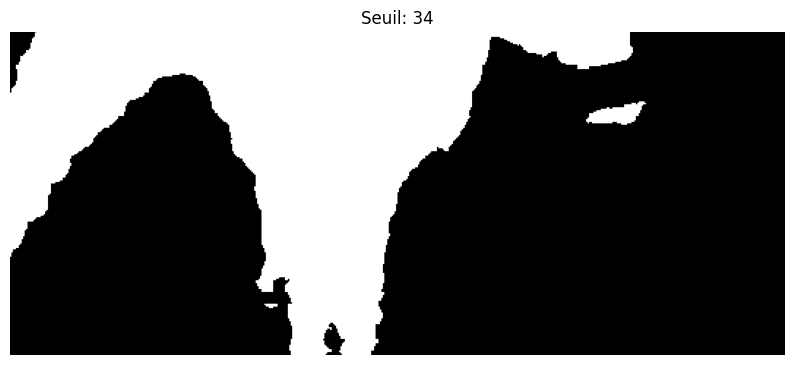

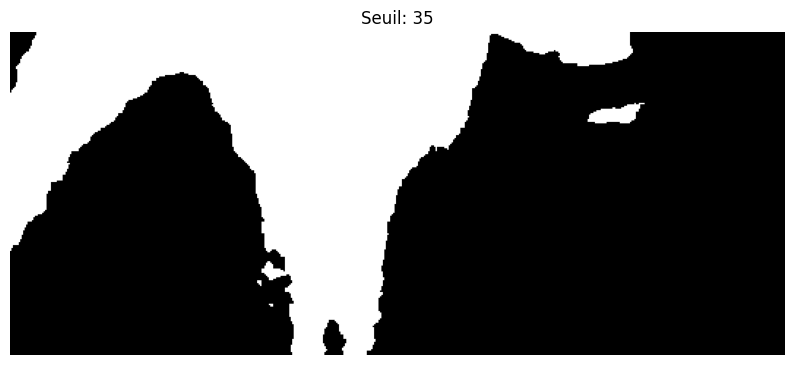

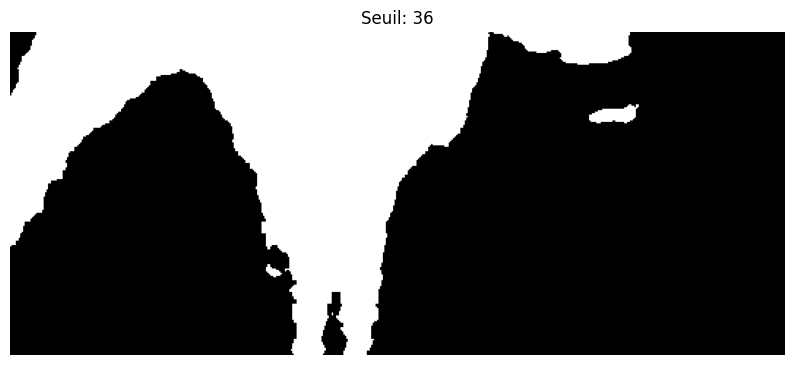

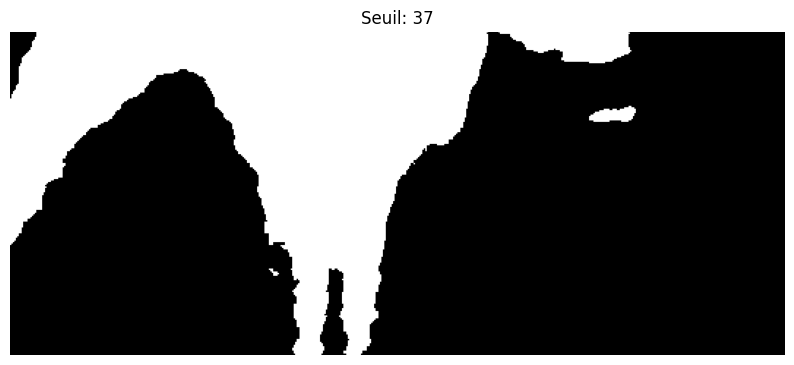

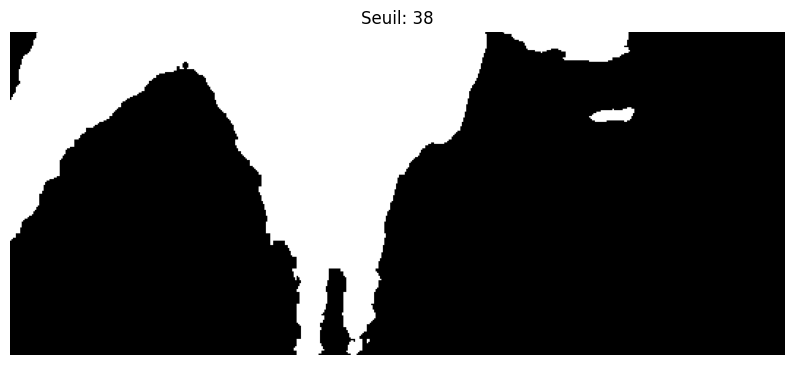

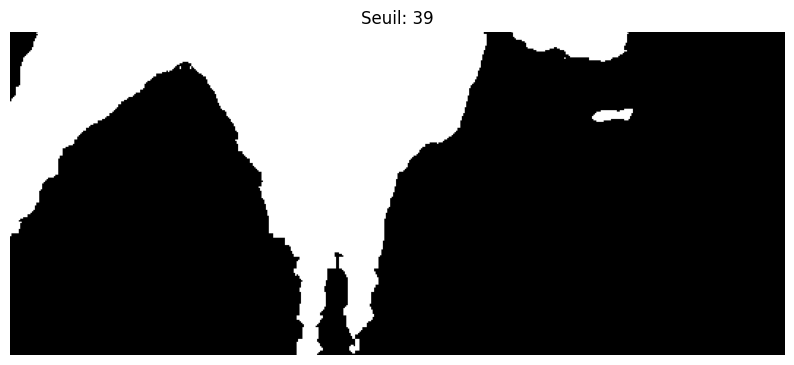

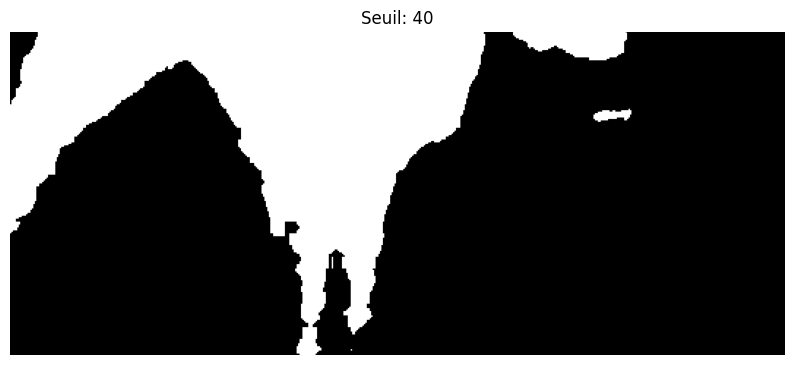

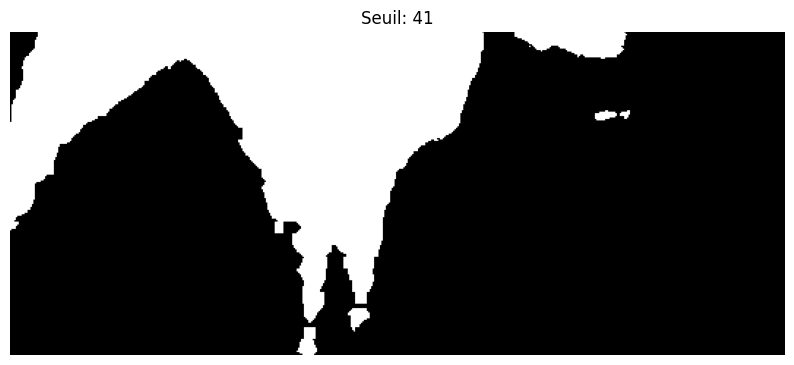

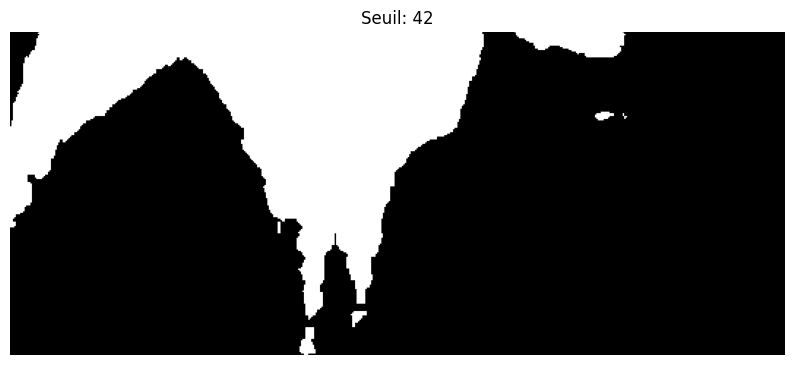

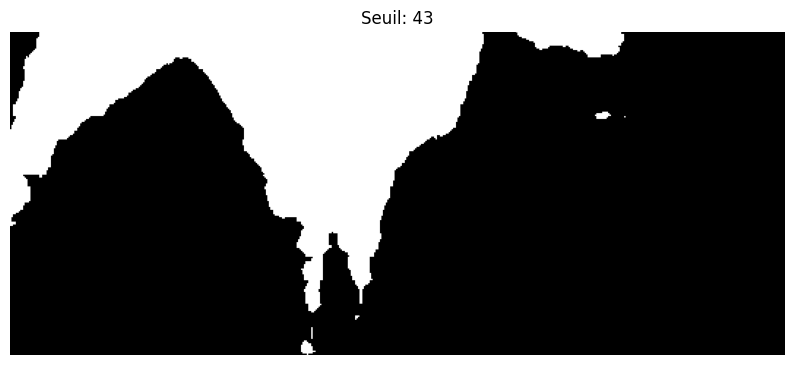

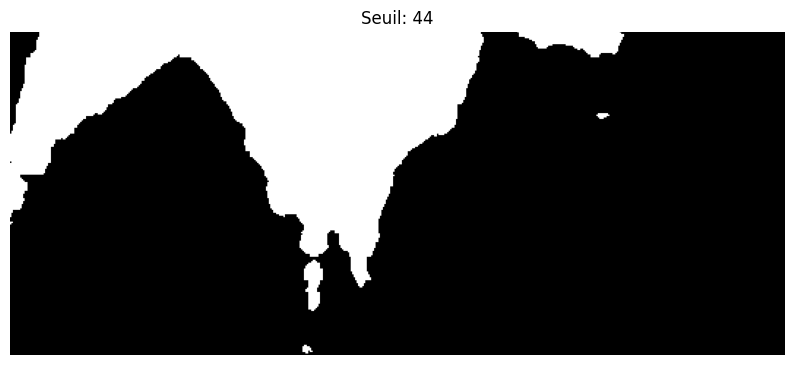

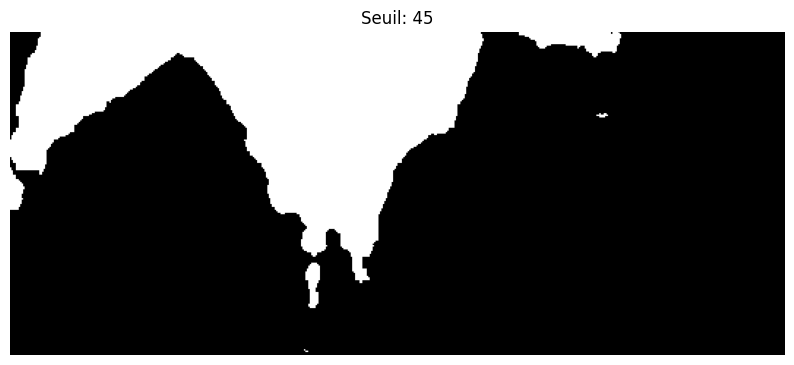

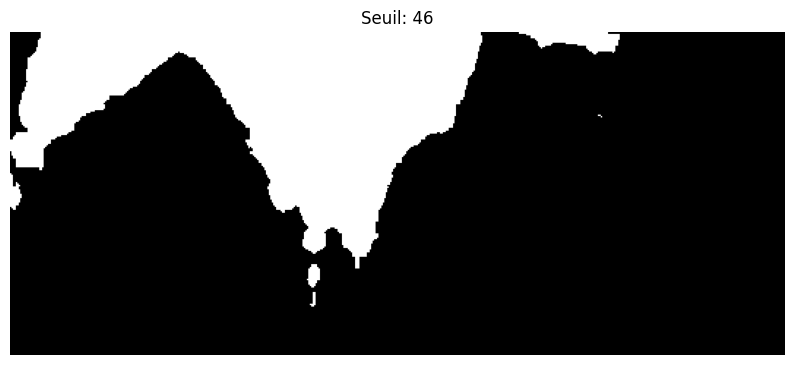

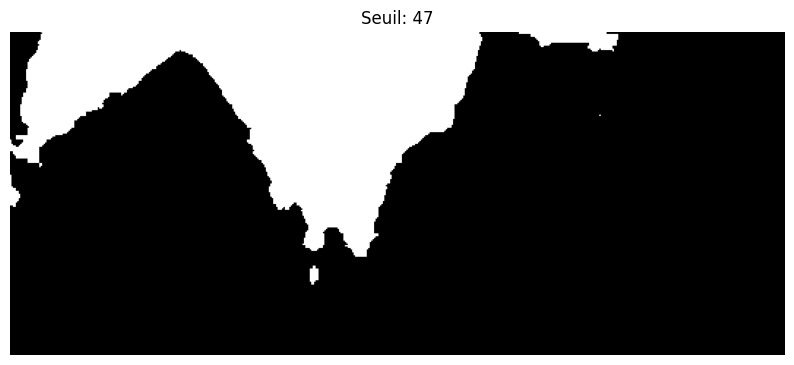

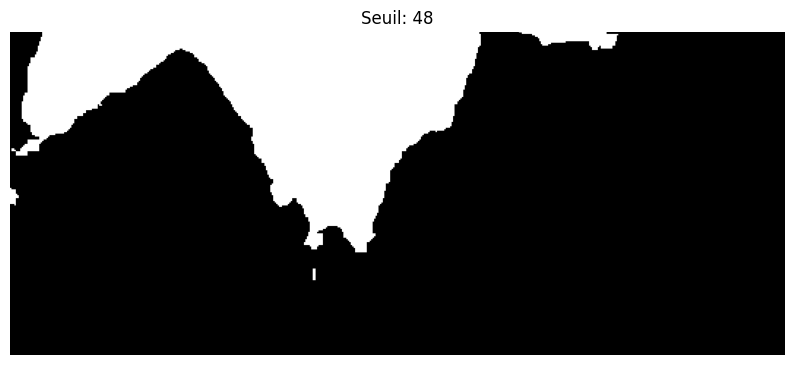

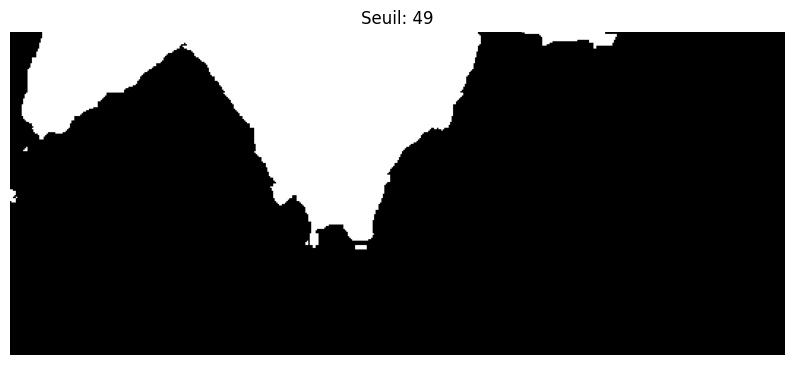

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# image = cv2.imread('Patients/Patients/20Patient 1LC20/1020M0/201902/2019010K.jpg', cv2.IMREAD_GRAYSCALE)
image = cv2.imread('foo.jpg', cv2.IMREAD_GRAYSCALE)

margin = 50 
height, width = image.shape[:2]

cropped_image = image[margin:height-margin, margin:width-margin]

equalized_image = cv2.equalizeHist(cropped_image)

blurred_image = cv2.GaussianBlur(equalized_image, (5, 5), 0)

binary_image = cv2.adaptiveThreshold(blurred_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    largest_contour = max(contours, key=cv2.contourArea)

    pleural_line_image = np.zeros_like(cropped_image)
    cv2.drawContours(pleural_line_image, [largest_contour], -1, (255), thickness=cv2.FILLED)

    pleural_line_y = int(np.mean(largest_contour[:, :, 1]))

    below_pleural_line = cropped_image[pleural_line_y:height-margin, margin:width-margin]

    for threshold in range(30, 50, 1):
        _, binary_below = cv2.threshold(below_pleural_line, threshold, 255, cv2.THRESH_BINARY)

        contours_below, _ = cv2.findContours(binary_below, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        output_below = np.zeros_like(below_pleural_line)

        cv2.drawContours(output_below, contours_below, -1, (255), thickness=cv2.FILLED)

        plt.figure(figsize=(10, 5))
        plt.imshow(output_below, cmap='gray')
        plt.title(f'Seuil: {threshold}')
        plt.axis('off')
        plt.show()
else:
    print("Aucun contour trouvé.")
